In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

CICIDS_PATH = r'C:\Users\o\OneDrive\Desktop\University\6 Semester\Deep Learning Lab\Datasets\CIC-IDS- 2017'
UNSW_PATH    = r'C:\Users\o\OneDrive\Desktop\University\6 Semester\Deep Learning Lab\Datasets\UNSW-NB15'
NSL_PATH     = r'C:\Users\o\OneDrive\Desktop\University\6 Semester\Deep Learning Lab\Datasets\NSL-KDD'
RESULTS_PATH = r'C:\Users\o\OneDrive\Desktop\University\6 Semester\Deep Learning Lab\Datasets\results'

os.makedirs(RESULTS_PATH, exist_ok=True)

print('Checking dataset folders...')
for name, path in [('CICIDS2017', CICIDS_PATH),
                   ('UNSW-NB15',  UNSW_PATH),
                   ('NSL-KDD',    NSL_PATH)]:
    if os.path.exists(path):
        files = os.listdir(path)
        print(f'  {name} found — {len(files)} files: {files[:3]}')
    else:
        print(f'  {name} NOT FOUND at:')
        print(f'     {path}')
        print(f'     Please fix this path before continuing')

print(f'\nLibraries imported successfully')
print(f'Results will save to: {RESULTS_PATH}')

Checking dataset folders...
  CICIDS2017 found — 8 files: ['Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv']
  UNSW-NB15 found — 2 files: ['UNSW_NB15_testing-set.parquet', 'UNSW_NB15_training-set.parquet']
  NSL-KDD found — 12 files: ['index.html', 'KDDTest+.arff', 'KDDTest+.txt']

Libraries imported successfully
Results will save to: C:\Users\o\OneDrive\Desktop\University\6 Semester\Deep Learning Lab\Datasets\results


In [3]:
print('Loading CICIDS2017...')
cicids_files = [f for f in os.listdir(CICIDS_PATH) if f.endswith('.csv')]
print(f'Found {len(cicids_files)} CSV files:')

dfs = []
for f in cicids_files:
    df = pd.read_csv(os.path.join(CICIDS_PATH, f), low_memory=False)
    dfs.append(df)
    print(f'  Loaded: {f}  →  {len(df):,} rows')

cicids = pd.concat(dfs, ignore_index=True)

cicids.columns = cicids.columns.str.strip()

print(f'\n✅ CICIDS2017 loaded successfully')
print(f'   Total rows:    {len(cicids):,}')
print(f'   Total columns: {cicids.shape[1]}')

Loading CICIDS2017...
Found 8 CSV files:
  Loaded: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv  →  225,745 rows
  Loaded: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv  →  286,467 rows
  Loaded: Friday-WorkingHours-Morning.pcap_ISCX.csv  →  191,033 rows
  Loaded: Monday-WorkingHours.pcap_ISCX.csv  →  529,918 rows
  Loaded: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  →  288,602 rows
  Loaded: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  →  170,366 rows
  Loaded: Tuesday-WorkingHours.pcap_ISCX.csv  →  445,909 rows
  Loaded: Wednesday-workingHours.pcap_ISCX.csv  →  692,703 rows

✅ CICIDS2017 loaded successfully
   Total rows:    2,830,743
   Total columns: 79


In [6]:
print('CICIDS2017 — First 5 rows:')
display(cicids.head())

print('\nAll column names (the 79 features):')
for i, col in enumerate(cicids.columns):
    print(f'  {i+1:>3}. {col}')

CICIDS2017 — First 5 rows:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN



All column names (the 79 features):
    1. Destination Port
    2. Flow Duration
    3. Total Fwd Packets
    4. Total Backward Packets
    5. Total Length of Fwd Packets
    6. Total Length of Bwd Packets
    7. Fwd Packet Length Max
    8. Fwd Packet Length Min
    9. Fwd Packet Length Mean
   10. Fwd Packet Length Std
   11. Bwd Packet Length Max
   12. Bwd Packet Length Min
   13. Bwd Packet Length Mean
   14. Bwd Packet Length Std
   15. Flow Bytes/s
   16. Flow Packets/s
   17. Flow IAT Mean
   18. Flow IAT Std
   19. Flow IAT Max
   20. Flow IAT Min
   21. Fwd IAT Total
   22. Fwd IAT Mean
   23. Fwd IAT Std
   24. Fwd IAT Max
   25. Fwd IAT Min
   26. Bwd IAT Total
   27. Bwd IAT Mean
   28. Bwd IAT Std
   29. Bwd IAT Max
   30. Bwd IAT Min
   31. Fwd PSH Flags
   32. Bwd PSH Flags
   33. Fwd URG Flags
   34. Bwd URG Flags
   35. Fwd Header Length
   36. Bwd Header Length
   37. Fwd Packets/s
   38. Bwd Packets/s
   39. Min Packet Length
   40. Max Packet Length
   41. Packet 

Attack types in CICIDS2017 and sample counts:


,count
Label,
BENIGN,2273097
DoS Hulk,231073
PortScan,158930
DDoS,128027
DoS GoldenEye,10293
FTP-Patator,7938
SSH-Patator,5897
DoS slowloris,5796
DoS Slowhttptest,5499


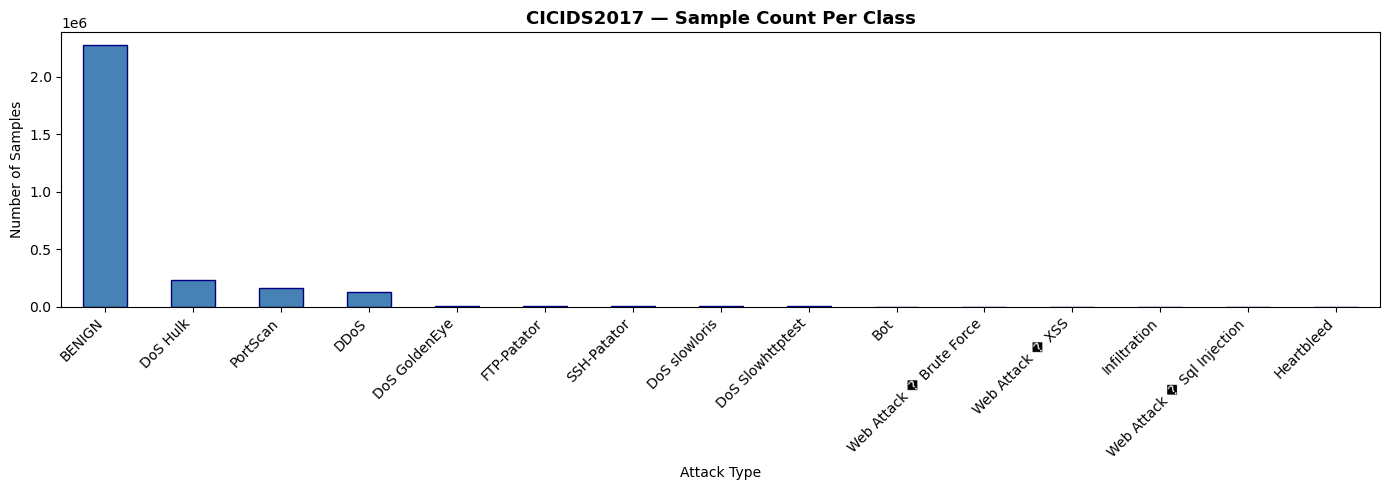

In [7]:
label_col = 'Label' if 'Label' in cicids.columns else ' Label'

print('Attack types in CICIDS2017 and sample counts:')
attack_counts = cicids[label_col].value_counts()
display(attack_counts.to_frame())

plt.figure(figsize=(14, 5))
attack_counts.plot(kind='bar', color='steelblue', edgecolor='navy')
plt.title('CICIDS2017 — Sample Count Per Class', fontweight='bold', fontsize=13)
plt.xlabel('Attack Type')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'cicids_class_distribution.png'), dpi=150)
plt.show()

benign_count = attack_counts.get('BENIGN', 0)


In [8]:
print('Loading UNSW-NB15...')
unsw_file = os.path.join(UNSW_PATH, 'UNSW_NB15_testing-set.parquet')
unsw = pd.read_parquet(unsw_file)

print(f'UNSW-NB15 loaded')
print(f'   Rows:    {len(unsw):,}')
print(f'   Columns: {unsw.shape[1]}')

print('\nUNSW-NB15 — First 5 rows:')
display(unsw.head())

unsw_label_cols = [c for c in unsw.columns
                   if 'label' in c.lower() or
                   'cat' in c.lower() or
                   'attack' in c.lower()]
print(f'\nLabel-related columns: {unsw_label_cols}')

if unsw_label_cols:
    print(f'\nAttack categories in UNSW-NB15:')
    display(unsw[unsw_label_cols[0]].value_counts().to_frame())

Loading UNSW-NB15...
UNSW-NB15 loaded
   Rows:    82,332
   Columns: 36

UNSW-NB15 — First 5 rows:


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.000011,udp,-,INT,2,0,496,0,90909.09375,180363632.0,...,0,0,1,1,0,0,0,0,Normal,0
1,0.000008,udp,-,INT,2,0,1762,0,125000.00000,881000000.0,...,0,0,1,1,0,0,0,0,Normal,0
2,0.000005,udp,-,INT,2,0,1068,0,200000.00000,854400000.0,...,0,0,1,1,0,0,0,0,Normal,0
3,0.000006,udp,-,INT,2,0,900,0,166666.65625,600000000.0,...,0,0,2,1,0,0,0,0,Normal,0
4,0.000010,udp,-,INT,2,0,2126,0,100000.00000,850400000.0,...,0,0,2,1,0,0,0,0,Normal,0



Label-related columns: ['attack_cat', 'label']

Attack categories in UNSW-NB15:


,count
attack_cat,
Normal,37000
Generic,18871
Exploits,11132
Fuzzers,6062
DoS,4089
Reconnaissance,3496
Analysis,677
Backdoor,583
Shellcode,378


In [9]:
print('Loading NSL-KDD...')

col_names = [
    'duration','protocol_type','service','flag',
    'src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',
    'num_failed_logins','logged_in','num_compromised','root_shell',
    'su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
    'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','label','difficulty'
]

nsl = pd.read_csv(
    os.path.join(NSL_PATH, 'KDDTest+.txt'),
    header=None,
    names=col_names
)

print(f'✅ NSL-KDD loaded')
print(f'   Rows:    {len(nsl):,}')
print(f'   Columns: {nsl.shape[1]}')

print('\nNSL-KDD — First 5 rows:')
display(nsl.head())

print('\nAttack types in NSL-KDD:')
display(nsl['label'].value_counts().head(15).to_frame())

Loading NSL-KDD...
✅ NSL-KDD loaded
   Rows:    22,544
   Columns: 43

NSL-KDD — First 5 rows:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11



Attack types in NSL-KDD:


,count
label,
normal,9711
neptune,4657
guess_passwd,1231
mscan,996
warezmaster,944
apache2,737
satan,735
processtable,685
smurf,665


In [10]:
# dataset size
print("CICIDS2017:", len(cicids), "rows")
print("UNSW-NB15:", len(unsw), "rows")
print("NSL-KDD:", len(nsl), "rows")

# attack types
print("\nCICIDS2017 attacks:")
print(cicids[label_col].unique())

print("\nUNSW-NB15 attacks:")
print(unsw[unsw_label_cols[0]].unique())

print("\nNSL-KDD attacks:")
print(nsl['label'].unique())

print("\nModel is trained only on CICIDS2017.")
print("UNSW-NB15 and NSL-KDD are used only for testing.")

CICIDS2017: 2830743 rows
UNSW-NB15: 82332 rows
NSL-KDD: 22544 rows

CICIDS2017 attacks:
['BENIGN' 'DDoS' 'PortScan' 'Bot' 'Infiltration'
 'Web Attack � Brute Force' 'Web Attack � XSS'
 'Web Attack � Sql Injection' 'FTP-Patator' 'SSH-Patator' 'DoS slowloris'
 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye' 'Heartbleed']

UNSW-NB15 attacks:
['Normal', 'Reconnaissance', 'Backdoor', 'DoS', 'Exploits', 'Analysis', 'Fuzzers', 'Worms', 'Shellcode', 'Generic']
Categories (10, object): ['Analysis', 'Backdoor', 'DoS', 'Exploits', ..., 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']

NSL-KDD attacks:
['neptune' 'normal' 'saint' 'mscan' 'guess_passwd' 'smurf' 'apache2'
 'satan' 'buffer_overflow' 'back' 'warezmaster' 'snmpgetattack'
 'processtable' 'pod' 'httptunnel' 'nmap' 'ps' 'snmpguess' 'ipsweep'
 'mailbomb' 'portsweep' 'multihop' 'named' 'sendmail' 'loadmodule' 'xterm'
 'worm' 'teardrop' 'rootkit' 'xlock' 'perl' 'land' 'xsnoop' 'sqlattack'
 'ftp_write' 'imap' 'udpstorm' 'phf']

Model is traine

In [12]:
#cleaning CICIDS2017 dataset

print('Removing invalid values from CICIDS2017...')

cicids.rename(columns={label_col: 'label'}, inplace=True)

cicids.replace([np.inf, -np.inf], np.nan, inplace=True)
before = len(cicids)
cicids.dropna(inplace=True)
after = len(cicids)
print(f'  Removed {before - after:,} invalid rows')
print(f'  Remaining: {after:,} rows')

print('\nFixing class imbalance...')

benign  = cicids[cicids['label'] == 'BENIGN']
attacks = cicids[cicids['label'] != 'BENIGN']

benign_sampled = benign.sample(
    n=min(len(benign), len(attacks) * 3),
    random_state=42
)
cicids_bal = pd.concat([benign_sampled, attacks]).sample(frac=1, random_state=42)

print(f'  BENIGN before: {len(benign):,}')
print(f'  BENIGN after:  {len(benign_sampled):,}')
print(f'  Attacks:       {len(attacks):,}')
print(f'  Total dataset: {len(cicids_bal):,}')

print('\nSTEP 3: Encoding text labels to numbers...')
le = LabelEncoder()
cicids_bal['label_enc'] = le.fit_transform(cicids_bal['label'])
n_classes = len(le.classes_)
print(f'  Number of classes: {n_classes}')
print(f'  Classes: {list(le.classes_)}')

print('\nCleaning and balancing complete')

Removing invalid values from CICIDS2017...
  Removed 0 invalid rows
  Remaining: 2,827,876 rows

Fixing class imbalance...
  BENIGN before: 2,271,320
  BENIGN after:  1,669,668
  Attacks:       556,556
  Total dataset: 2,226,224

STEP 3: Encoding text labels to numbers...
  Number of classes: 15
  Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']

Cleaning and balancing complete


In [13]:
print('Preparing features, normalizing, splitting...')

feature_cols = cicids_bal.select_dtypes(include=[np.number]).columns.tolist()
if 'label_enc' in feature_cols:
    feature_cols.remove('label_enc')
n_features = len(feature_cols)
print(f'  Number of features: {n_features}')

X = cicids_bal[feature_cols].values
y = cicids_bal['label_enc'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_s = np.clip(scaler.fit_transform(X_train_raw), 0, 1)
X_test_s  = np.clip(scaler.transform(X_test_raw),      0, 1)

# Prepare UNSW-NB15 
print('\n  Preparing UNSW-NB15 for testing...')
unsw_clean = unsw.copy()
unsw_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
unsw_clean.dropna(inplace=True)
unsw_numeric = unsw_clean.select_dtypes(include=[np.number]).columns.tolist()
for col in ['label', 'Label', 'id', 'attack_cat']:
    if col in unsw_numeric:
        unsw_numeric.remove(col)
X_unsw_raw = unsw_clean[unsw_numeric].values

if X_unsw_raw.shape[1] < n_features:
    pad = np.zeros((len(X_unsw_raw), n_features - X_unsw_raw.shape[1]))
    X_unsw_raw = np.hstack([X_unsw_raw, pad])
else:
    X_unsw_raw = X_unsw_raw[:, :n_features]

X_unsw_s = np.clip(scaler.transform(X_unsw_raw), 0, 1)

# Prepare NSL-KDD 
print('  Preparing NSL-KDD for testing...')
nsl_clean = nsl.copy()
nsl_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
nsl_clean.dropna(inplace=True)
nsl_numeric = nsl_clean.select_dtypes(include=[np.number]).columns.tolist()
for col in ['label', 'difficulty']:
    if col in nsl_numeric:
        nsl_numeric.remove(col)
X_nsl_raw = nsl_clean[nsl_numeric].values
if X_nsl_raw.shape[1] < n_features:
    pad = np.zeros((len(X_nsl_raw), n_features - X_nsl_raw.shape[1]))
    X_nsl_raw = np.hstack([X_nsl_raw, pad])
else:
    X_nsl_raw = X_nsl_raw[:, :n_features]
X_nsl_s = np.clip(scaler.transform(X_nsl_raw), 0, 1)

print(f'\n  Training set:          {X_train_s.shape}')
print(f'  Test set (known):      {X_test_s.shape}')
print(f'  UNSW-NB15 (unknown):   {X_unsw_s.shape}')
print(f'  NSL-KDD (unknown):     {X_nsl_s.shape}')

Preparing features, normalizing, splitting...
  Number of features: 78

  Preparing UNSW-NB15 for testing...
  Preparing NSL-KDD for testing...

  Training set:          (1780979, 78)
  Test set (known):      (445245, 78)
  UNSW-NB15 (unknown):   (82332, 78)
  NSL-KDD (unknown):     (22544, 78)


In [14]:
#BASELINE LSTM (THE OLD APPROACH)

In [15]:
print('Building Baseline LSTM...')


X_train_lstm = X_train_s.reshape(X_train_s.shape[0], 1, n_features)
X_test_lstm  = X_test_s.reshape(X_test_s.shape[0],   1, n_features)
X_unsw_lstm  = X_unsw_s.reshape(X_unsw_s.shape[0],   1, n_features)
X_nsl_lstm   = X_nsl_s.reshape(X_nsl_s.shape[0],     1, n_features)


y_train_cat = to_categorical(y_train, n_classes)

baseline = Sequential([
    LSTM(128, input_shape=(1, n_features), return_sequences=True),
    Dropout(0.3), 
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(n_classes, activation='softmax')
])

baseline.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline.summary()


early_stop = EarlyStopping(patience=5, restore_best_weights=True, verbose=1)

print('\nTraining baseline LSTM on CICIDS2017...')
history_baseline = baseline.fit(
    X_train_lstm, y_train_cat,
    epochs=30,
    batch_size=512,
    validation_split=0.1,  
    callbacks=[early_stop],
    verbose=1
)

print('\nBaseline LSTM training complete')

Building Baseline LSTM...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 1, 128)              │         105,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 15)                  │             495 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 157,967 (617.06 KB)

 Trainable params: 157,967 (617.06 KB)

 Non-trainable params: 0 (0.00 B)


Training baseline LSTM on CICIDS2017...
Epoch 1/30
3131/3131 ━━━━━━━━━━━━━━━━━━━━ 77s 19ms/step - accuracy: 0.9305 - loss: 0.2279 - val_accuracy: 0.9604 - val_loss: 0.1048
Epoch 2/30
3131/3131 ━━━━━━━━━━━━━━━━━━━━ 58s 18ms/step - accuracy: 0.9646 - loss: 0.0948 - val_accuracy: 0.9712 - val_loss: 0.0785
Epoch 3/30
3131/3131 ━━━━━━━━━━━━━━━━━━━━ 59s 19ms/step - accuracy: 0.9707 - loss: 0.0774 - val_accuracy: 0.9781 - val_loss: 0.0609
Epoch 4/30
3131/3131 ━━━━━━━━━━━━━━━━━━━━ 57s 18ms/step - accuracy: 0.9755 - loss: 0.0653 - val_accuracy: 0.9786 - val_loss: 0.0562
Epoch 5/30
3131/3131 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.9771 - loss: 0.0596 - val_accuracy: 0.9794 - val_loss: 0.0526
Epoch 6/30
3131/3131 ━━━━━━━━━━━━━━━━━━━━ 64s 20ms/step - accuracy: 0.9781 - loss: 0.0561 - val_accuracy: 0.9797 - val_loss: 0.0555
Epoch 7/30
3131/3131 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.9789 - loss: 0.0534 - val_accuracy: 0.9809 - val_loss: 0.0480
Epoch 8/30
3131/3131 ━━━━━━━━━━━━━━

In [16]:
print('BASELINE EVALUATION — KNOWN ATTACKS (CICIDS2017 test set)')

y_pred_proba = baseline.predict(X_test_lstm, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f'\nOverall Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
print(f'Overall F1 Score : {f1:.4f}')
print('\nPer-class results:')
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_,
    zero_division=0
))

BASELINE EVALUATION — KNOWN ATTACKS (CICIDS2017 test set)

Overall Accuracy : 0.9847  (98.47%)
Overall F1 Score : 0.9845

Per-class results:
                            precision    recall  f1-score   support

                    BENIGN       0.99      0.99      0.99    333934
                       Bot       0.65      0.60      0.62       391
                      DDoS       1.00      1.00      1.00     25605
             DoS GoldenEye       0.98      0.99      0.99      2059
                  DoS Hulk       0.97      0.99      0.98     46025
          DoS Slowhttptest       0.97      0.99      0.98      1100
             DoS slowloris       0.98      0.98      0.98      1159
               FTP-Patator       1.00      1.00      1.00      1587
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       0.00      0.00      0.00         7
                  PortScan       0.91      0.96      0.94     31761
               SSH-Patator       0.97     

In [17]:
print('BASELINE EVALUATION — UNKNOWN ATTACKS (UNSW-NB15)')
print(f'\nFeeding {len(X_unsw_lstm):,} unknown attacks to the baseline...')

unsw_proba = baseline.predict(X_unsw_lstm, verbose=0)
unsw_pred  = np.argmax(unsw_proba, axis=1)
unsw_conf  = np.max(unsw_proba, axis=1)  

print('What the baseline THINKS these unknown attacks are:')
for class_idx in np.unique(unsw_pred):
    mask       = unsw_pred == class_idx
    count      = mask.sum()
    avg_conf   = unsw_conf[mask].mean()
    class_name = le.classes_[class_idx]
    print(f'  Predicted as "{class_name}": {count:,} samples'
          f'  (avg confidence {avg_conf*100:.1f}%)')

avg_conf_unknown = unsw_conf.mean()

print(f'\nAverage confidence on UNKNOWN attacks: {avg_conf_unknown*100:.2f}%')
print(f'Unknown attacks flagged as suspicious:  0  (0.00%)')
print(f'THIS MODEL IS CONFIDENTLY WRONG')
print(f'\n   {len(X_unsw_lstm):,} real attacks arrived from UNSW-NB15')
print(f'   The model called them ALL normal traffic')
print(f'   With {avg_conf_unknown*100:.2f}% average confidence')
print(f'   In a real network — every single attacker gets through undetected')

BASELINE EVALUATION — UNKNOWN ATTACKS (UNSW-NB15)

Feeding 82,332 unknown attacks to the baseline...
What the baseline THINKS these unknown attacks are:
  Predicted as "BENIGN": 82,057 samples  (avg confidence 91.2%)
  Predicted as "Bot": 1 samples  (avg confidence 55.8%)
  Predicted as "DoS GoldenEye": 255 samples  (avg confidence 98.5%)
  Predicted as "DoS Slowhttptest": 19 samples  (avg confidence 73.7%)

Average confidence on UNKNOWN attacks: 91.25%
Unknown attacks flagged as suspicious:  0  (0.00%)
THIS MODEL IS CONFIDENTLY WRONG

   82,332 real attacks arrived from UNSW-NB15
   The model called them ALL normal traffic
   With 91.25% average confidence
   In a real network — every single attacker gets through undetected


In [18]:
#Autoencoder based open set detection

In [19]:
print('Autoencoder')

ae_input = Input(shape=(n_features,))

encoded = Dense(64, activation='relu')(ae_input)  
encoded = Dense(32, activation='relu')(encoded)    
encoded = Dense(16, activation='relu')(encoded)   

decoded = Dense(32, activation='relu')(encoded)   
decoded = Dense(64, activation='relu')(decoded)   
decoded = Dense(n_features, activation='sigmoid')(decoded)  

autoencoder = Model(ae_input, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

ae_stop = EarlyStopping(patience=5, restore_best_weights=True, verbose=1)
print('\nTraining autoencoder on CICIDS2017 known traffic only...')
history_ae = autoencoder.fit(
    X_train_s, X_train_s,  # Input and target are the SAME
    epochs=50,
    batch_size=512,
    validation_split=0.1,
    callbacks=[ae_stop],
    verbose=1
)
print('\n✅ Autoencoder trained on Dataset CICIDS2017')

Autoencoder


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 78)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           5,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 78)                  │           5,070 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,390 (60.12 KB)

 Trainable params: 15,390 (60.12 KB)

 Non-trainable params: 0 (0.00 B)


Training autoencoder on CICIDS2017 known traffic only...
Epoch 1/50
3131/3131 ━━━━━━━━━━━━━━━━━━━━ 37s 10ms/step - loss: 0.0050 - val_loss: 0.0015
Epoch 2/50
3131/3131 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 3/50
3131/3131 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 4/50
3131/3131 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 5/50
3131/3131 ━━━━━━━━━━━━━━━━━━━━ 46s 8ms/step - loss: 0.0010 - val_loss: 5.8240e-04
Epoch 6/50
3131/3131 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5.6925e-04 - val_loss: 5.6475e-04
Epoch 7/50
3131/3131 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 5.5808e-04 - val_loss: 4.5815e-04
Epoch 8/50
3131/3131 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 4.4084e-04 - val_loss: 4.4101e-04
Epoch 9/50
3131/3131 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 4.3196e-04 - val_loss: 4.3929e-04
Epoch 10/50
3131/3131 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 4.2824e-04 - val_loss: 4.3331e-04
Epoch 

In [20]:
print('CALCULATING RECONSTRUCTION ERRORS')

recon_test = autoencoder.predict(X_test_s, verbose=0)
recon_unsw = autoencoder.predict(X_unsw_s, verbose=0)
recon_nsl  = autoencoder.predict(X_nsl_s,  verbose=0)

err_test = np.mean(np.square(X_test_s - recon_test), axis=1)
err_unsw = np.mean(np.square(X_unsw_s - recon_unsw), axis=1)
err_nsl  = np.mean(np.square(X_nsl_s  - recon_nsl),  axis=1)

print(f'\nReconstruction error on KNOWN traffic (CICIDS2017):')
print(f'  Mean:   {err_test.mean():.6f}   ← almost zero — autoencoder knows this traffic')
print(f'  Median: {np.median(err_test):.6f}')

print(f'\nReconstruction error on UNKNOWN attacks (UNSW-NB15):')
print(f'  Mean:   {err_unsw.mean():.6f}   ← massive — autoencoder has never seen this')
print(f'  Median: {np.median(err_unsw):.6f}')

print(f'\nReconstruction error on UNKNOWN attacks (NSL-KDD):')
print(f'  Mean:   {err_nsl.mean():.6f}   ← also high — 1999 attacks look nothing like 2017')
print(f'  Median: {np.median(err_nsl):.6f}')

gap_unsw = err_unsw.mean() / err_test.mean()
gap_nsl  = err_nsl.mean()  / err_test.mean()
print(f'\n UNSW unknown error is {gap_unsw:.0f}x LARGER than known traffic error')
print(f'NSL-KDD unknown error is {gap_nsl:.0f}x LARGER than known traffic error')
print(f'\n   This enormous gap is our suspicious signal')
print(f'High error = traffic the model has never seen = flag as suspicious')

CALCULATING RECONSTRUCTION ERRORS

Reconstruction error on KNOWN traffic (CICIDS2017):
  Mean:   0.000239   ← almost zero — autoencoder knows this traffic
  Median: 0.000002

Reconstruction error on UNKNOWN attacks (UNSW-NB15):
  Mean:   0.029923   ← massive — autoencoder has never seen this
  Median: 0.036099

Reconstruction error on UNKNOWN attacks (NSL-KDD):
  Mean:   0.010866   ← also high — 1999 attacks look nothing like 2017
  Median: 0.012656

 UNSW unknown error is 125x LARGER than known traffic error
NSL-KDD unknown error is 45x LARGER than known traffic error

   This enormous gap is our suspicious signal
High error = traffic the model has never seen = flag as suspicious


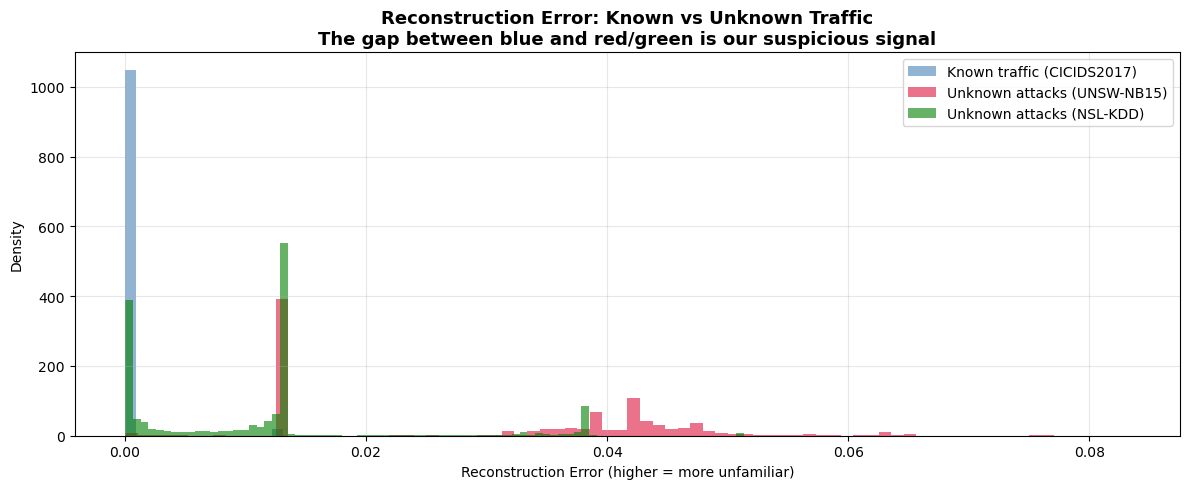

In [23]:
plt.figure(figsize=(12, 5))

plt.hist(err_test, bins=80, alpha=0.6, color='steelblue',
         label='Known traffic (CICIDS2017)', density=True)
plt.hist(err_unsw, bins=80, alpha=0.6, color='crimson',
         label='Unknown attacks (UNSW-NB15)', density=True)
plt.hist(err_nsl, bins=80, alpha=0.6, color='green',
         label='Unknown attacks (NSL-KDD)', density=True)

plt.title('Reconstruction Error: Known vs Unknown Traffic\n'
          'The gap between blue and red/green is our suspicious signal',
          fontweight='bold', fontsize=13)
plt.xlabel('Reconstruction Error (higher = more unfamiliar)')
plt.ylabel('Density')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'error_distributions.png'), dpi=150)
plt.show()

In [25]:
print('FINDING BEST RECONSTRUCTION ERROR THRESHOLD')

best_t     = 0
best_score = 0
rows       = []

for pct in range(50, 100, 2):
    threshold      = np.percentile(err_test, pct)
    known_pass     = (err_test < threshold).mean()   # % of known NOT flagged
    unknown_caught = (err_unsw >= threshold).mean()  # % of unknown flagged
    score          = unknown_caught * 0.7 + known_pass * 0.3
    rows.append((round(threshold, 6), pct, known_pass, unknown_caught, score))
    if score > best_score:
        best_score = score
        best_t     = threshold

print(f'{"Percentile":>12} {"Threshold":>12} '
      f'{"Known Pass":>12} {"Unknown Caught":>15} {"Score":>8}')
print('-'*65)
for t, pct, kp, uc, s in rows:
    marker = ' ← BEST' if abs(t - best_t) < 1e-8 else ''
    print(f'{pct:>12} {t:>12.6f} '
          f'{kp:>11.1%} {uc:>14.1%} {s:>7.4f}{marker}')

print(f'\n✅ Best threshold selected: {best_t:.6f}')
print(f'   At this threshold:')
print(f'   → Unknown attacks caught:       {(err_unsw >= best_t).mean():.1%}')
print(f'   → Known traffic correctly passed: {(err_test < best_t).mean():.1%}')

FINDING BEST RECONSTRUCTION ERROR THRESHOLD
  Percentile    Threshold   Known Pass  Unknown Caught    Score
-----------------------------------------------------------------
          50     0.000002       50.0%         100.0%  0.8500
          52     0.000002       52.0%         100.0%  0.8560
          54     0.000002       54.0%         100.0%  0.8620
          56     0.000002       56.0%         100.0%  0.8680
          58     0.000003       58.0%         100.0%  0.8740
          60     0.000003       60.0%         100.0%  0.8800
          62     0.000003       62.0%         100.0%  0.8860
          64     0.000004       64.0%         100.0%  0.8920
          66     0.000004       66.0%         100.0%  0.8980
          68     0.000004       68.0%         100.0%  0.9040
          70     0.000005       70.0%          99.9%  0.9091
          72     0.000005       72.0%          99.9%  0.9150
          74     0.000006       74.0%          99.9%  0.9210
          76     0.000007       7

In [29]:
print('FINAL RESULTS — suspecious MECHANISM APPLIED')

flagged_known  = (err_test >= best_t).sum()
passed_known   = (err_test <  best_t).sum()
false_unk_rate = flagged_known / len(err_test)

print(f'\nOn KNOWN traffic (CICIDS2017 test set):')
print(f'  Correctly passed through:   {passed_known:,} ({1-false_unk_rate:.1%})')
print(f'  Wrongly flagged as UNKNOWN: {flagged_known:,} ({false_unk_rate:.1%})  ← false alarm rate')

flagged_unsw = (err_unsw >= best_t).sum()
missed_unsw  = len(err_unsw) - flagged_unsw
unsw_rate    = flagged_unsw / len(err_unsw)

print(f'\nOn UNKNOWN attacks (UNSW-NB15 — never seen during training):')
print(f'Correctly flagged SUSPICIOUS: {flagged_unsw:,} ({unsw_rate:.1%})')
print(f'Missed (slipped through):     {missed_unsw:,} ({1-unsw_rate:.1%})')

flagged_nsl = (err_nsl >= best_t).sum()
missed_nsl  = len(err_nsl) - flagged_nsl
nsl_rate    = flagged_nsl / len(err_nsl)

print(f'\nOn UNKNOWN attacks (NSL-KDD — 1999 attacks, never seen):')
print(f'Correctly flagged SUSPICIOUS: {flagged_nsl:,} ({nsl_rate:.1%})')
print(f'Missed (slipped through):     {missed_nsl:,} ({1-nsl_rate:.1%})')

FINAL RESULTS — suspecious MECHANISM APPLIED

On KNOWN traffic (CICIDS2017 test set):
  Correctly passed through:   436,340 (98.0%)
  Wrongly flagged as UNKNOWN: 8,905 (2.0%)  ← false alarm rate

On UNKNOWN attacks (UNSW-NB15 — never seen during training):
Correctly flagged SUSPICIOUS: 81,978 (99.6%)
Missed (slipped through):     354 (0.4%)

On UNKNOWN attacks (NSL-KDD — 1999 attacks, never seen):
Correctly flagged SUSPICIOUS: 17,330 (76.9%)
Missed (slipped through):     5,214 (23.1%)


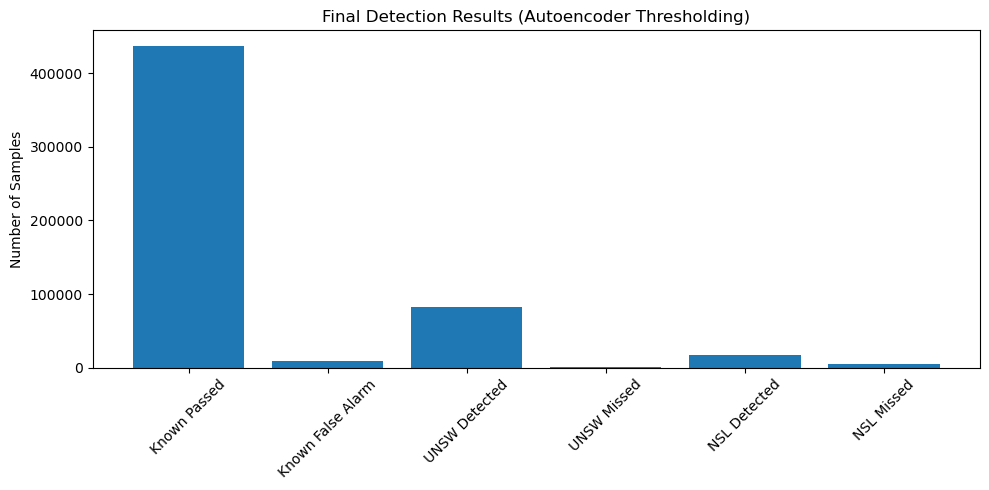

In [28]:
labels = [
    "Known Passed",
    "Known False Alarm",
    "UNSW Detected",
    "UNSW Missed",
    "NSL Detected",
    "NSL Missed"
]

values = [
    passed_known,
    flagged_known,
    flagged_unsw,
    missed_unsw,
    flagged_nsl,
    missed_nsl
]

plt.figure(figsize=(10,5))
plt.bar(labels, values)

plt.title("Final Detection Results (Autoencoder Thresholding)")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()